# Đề Tài: Student Exam Performance Dataset Analysis — nguồn Kaggle

Dataset tổng hợp các yếu tố ảnh hưởng đến điểm thi của học sinh. Phù hợp cho phân tích hồi quy và machine learning thực hành.
## Yêu cầu 
1. Chọn 1 dataset và huấn luyện mô hình với dataset đó.
2. Mô hình bao gồm : 1 baseline ,2 model nâng cao hơn.
3. Xây dưng mô mình tự implement và sklearn.  
4. Đánh giá mô hình bằng các tiêu chí MAE,RMSE,R2_SQUARE.
5. So sánh các model và kết luận.
## Task
1. EDA + Preprocessing.
2. Baseline Model — Linear Regression.
3. **Random Forest Regression** (tự implement và skearn).
4. **Gradient Boosting Regression** (tự implement và sklearn).
5. **So sánh** 3 model và kêt luận

---
## 1. EDA + Preprocessing



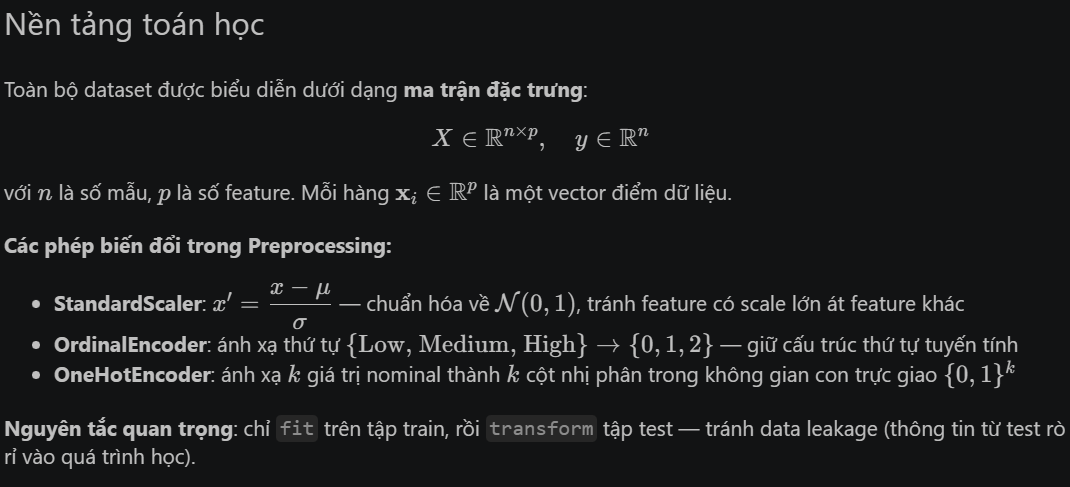

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from DB_connect import get_engine
# file_path = "StudentPerformanceFactors.csv"
# df = kagglehub.load_dataset(
#   KaggleDatasetAdapter.PANDAS,
#     "grandmaster07/student-exam-performance-dataset-analysis",
#   file_path,) 
engine = get_engine() 
df = pd.read_sql("SELECT * FROM student_performance_factors", con=engine)
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [4]:
df.describe(include='number')

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Giá trị thiếu:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64
Dòng trùng lặp: 0


C:\Users\admin\AppData\Local\Temp\ipykernel_27080\805535588.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cate_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\admin\AppData\Local\Temp\ipykernel_27080\805535588.py:21: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).



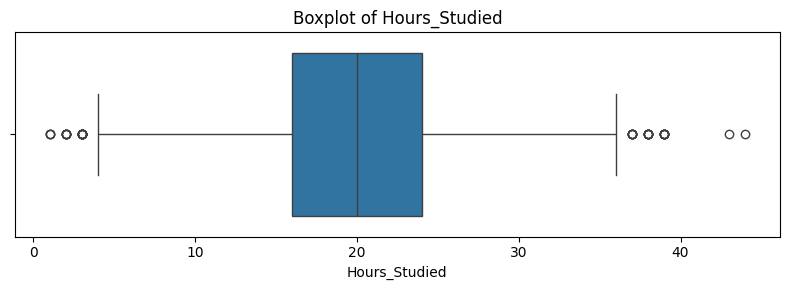

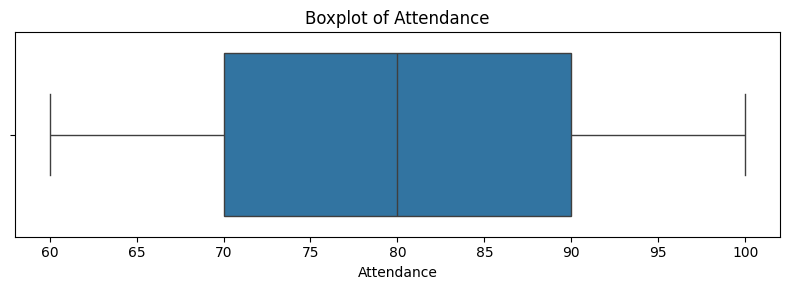

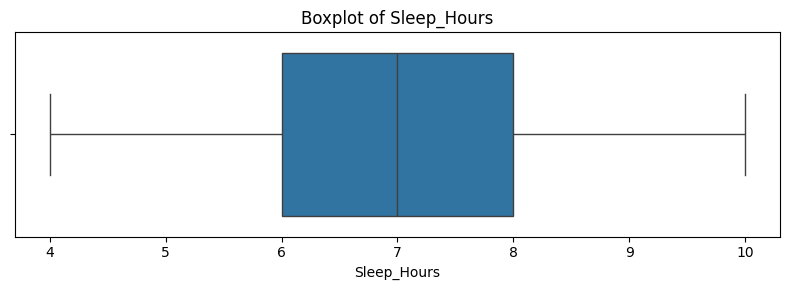

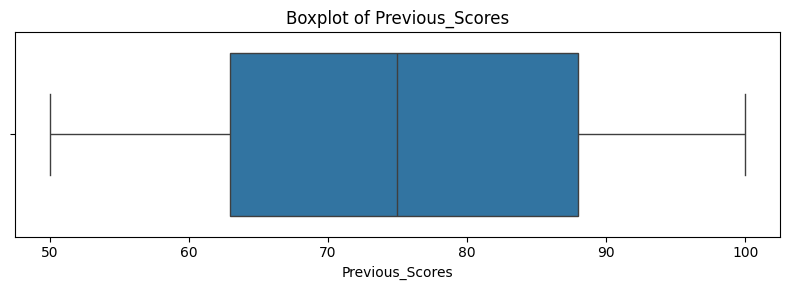

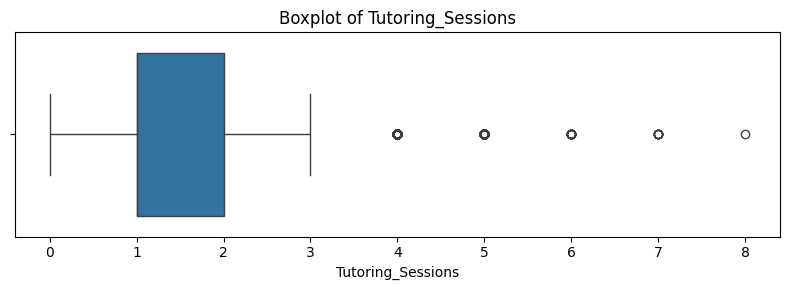

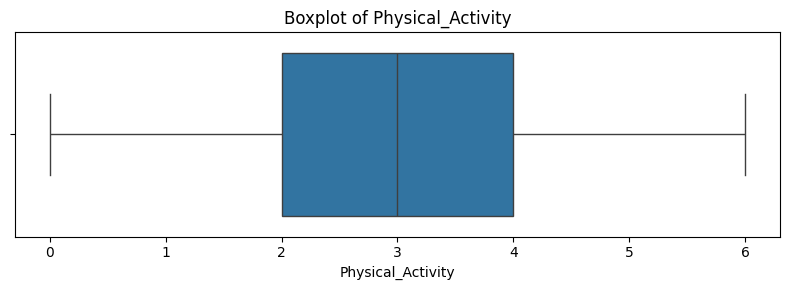

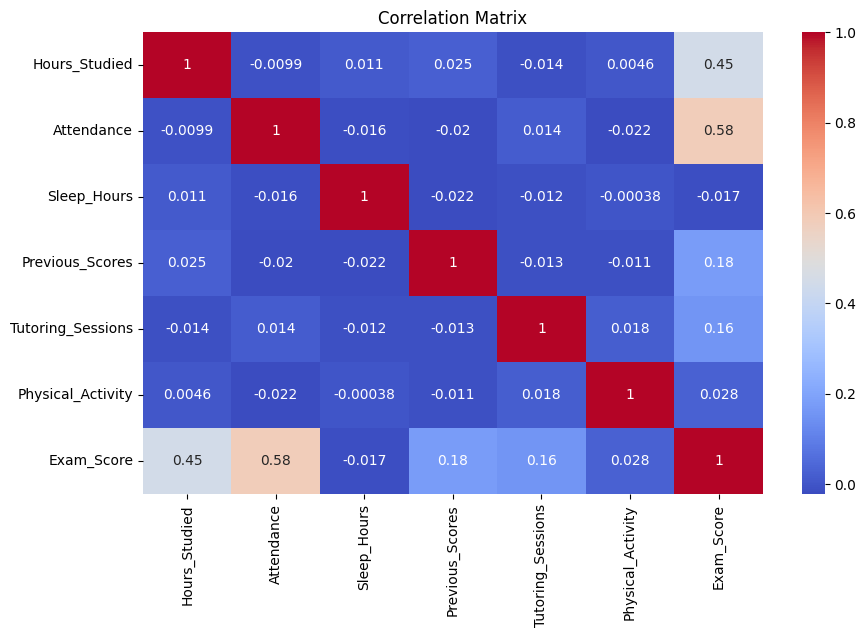

Shape train: (5285, 27)
Shape test:  (1322, 27)
Preprocessing hoàn tất


In [5]:
# ── 1. KIỂM TRA
missing_values = df.isnull().sum()
print(f'Giá trị thiếu:\n{missing_values[missing_values > 0]}')
duplicate_rows = df.duplicated().sum()
print(f'Dòng trùng lặp: {duplicate_rows}')
if duplicate_rows > 0:
    df = df.drop_duplicates().reset_index(drop=True)

# ── 2. TÁCH CỘT
num_cols  = df.select_dtypes(include=['number']).columns.tolist()
cate_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
target = 'Exam_Score'
feature_num_cols = [c for c in num_cols if c != target]

# ── 3. MISSING VALUES
for col in feature_num_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
for col in cate_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

# ── 4. VISUALIZE
for col in feature_num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout(); plt.show()

corr = df[num_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix'); plt.show()

# ── 5. IQR CLIPPING
for col in feature_num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# ── 6. TRAIN/TEST SPLIT
X = df[feature_num_cols + cate_cols]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ── 7. SCALING
scaler = StandardScaler()
X_train_scaled = X_train[feature_num_cols].copy()
X_test_scaled  = X_test[feature_num_cols].copy()
X_train_scaled[feature_num_cols] = scaler.fit_transform(X_train[feature_num_cols])
X_test_scaled[feature_num_cols]  = scaler.transform(X_test[feature_num_cols])

# ── 8. ENCODING
ordinal_cols = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Teacher_Quality',
    'Peer_Influence',
    'Distance_from_Home'
]

ordinal_orders = [
    ['Low', 'Medium', 'High'],          # Parental_Involvement
    ['Low', 'Medium', 'High'],          # Access_to_Resources
    ['Low', 'Medium', 'High'],          # Motivation_Level
    ['Low', 'Medium', 'High'],          # Family_Income
    ['Low', 'Medium', 'High'],          # Teacher_Quality
    ['Negative', 'Neutral', 'Positive'],# Peer_Influence
    ['Far', 'Moderate', 'Near']         # Distance_from_Home
]
nominal_cols = [c for c in cate_cols if c not in ordinal_cols]

oe = OrdinalEncoder(categories=ordinal_orders,
                    handle_unknown='use_encoded_value', unknown_value=-1)
ord_train = pd.DataFrame(oe.fit_transform(X_train[ordinal_cols]),
                         columns=ordinal_cols, index=X_train.index)
ord_test  = pd.DataFrame(oe.transform(X_test[ordinal_cols]),
                         columns=ordinal_cols, index=X_test.index)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_cols = ohe.fit(X_train[nominal_cols]).get_feature_names_out(nominal_cols)
ohe_train = pd.DataFrame(ohe.transform(X_train[nominal_cols]),
                         columns=ohe_cols, index=X_train.index)
ohe_test  = pd.DataFrame(ohe.transform(X_test[nominal_cols]),
                         columns=ohe_cols, index=X_test.index)

X_train_final = pd.concat([X_train_scaled, ord_train, ohe_train], axis=1)
X_test_final  = pd.concat([X_test_scaled,  ord_test,  ohe_test],  axis=1)
feature_names = X_train_final.columns.tolist()

print('Shape train:', X_train_final.shape)
print('Shape test: ', X_test_final.shape)
print('Preprocessing hoàn tất')

---
## 2. Baseline Model — Linear Regression

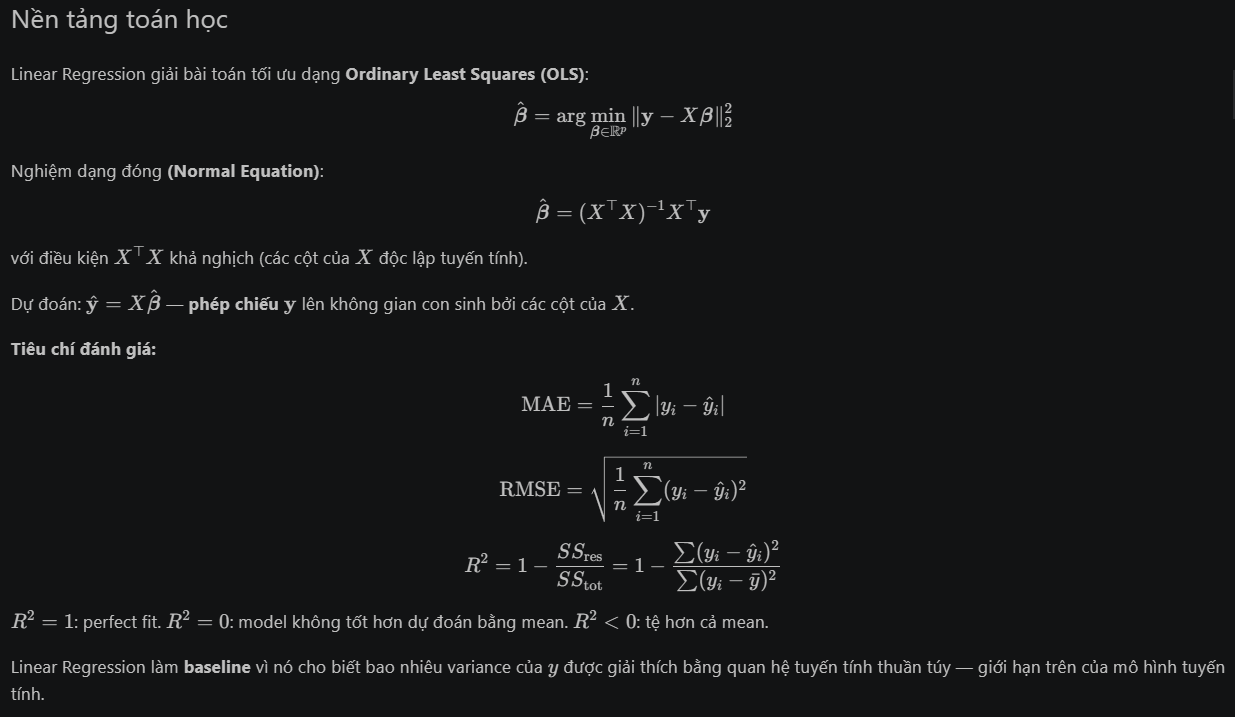

BASELINE - Linear Regression
MAE  : 0.4794
RMSE : 1.8127
R2   : 0.7675


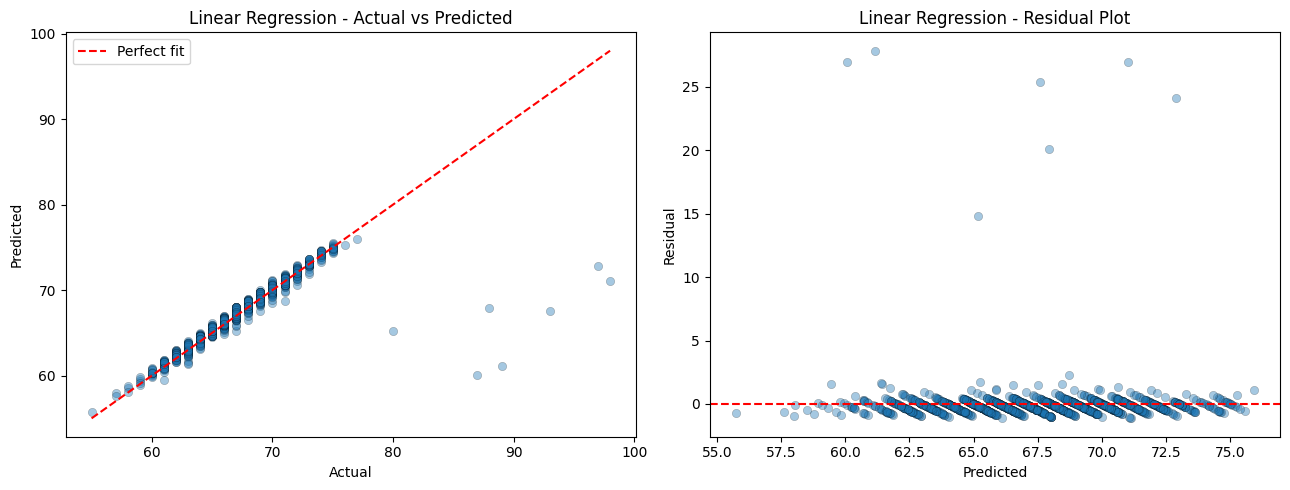

In [6]:
lr = LinearRegression()
lr.fit(X_train_final, y_train)
y_pred_lr = lr.predict(X_test_final)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('=' * 40)
print('BASELINE - Linear Regression')
print('=' * 40)
print(f'MAE  : {mae_lr:.4f}')
print(f'RMSE : {rmse_lr:.4f}')
print(f'R2   : {r2_lr:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, y_pred_lr, alpha=0.4, edgecolors='k', linewidths=0.3)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Linear Regression - Actual vs Predicted')
axes[0].legend()
residuals = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.4, edgecolors='k', linewidths=0.3)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Linear Regression - Residual Plot')
plt.tight_layout(); plt.show()

---
## 3. Random Forest Regression (tự implement và sklearn)

### 3.1. Random Forest Regression (implement)
#### Thuật toán Random Forest Regression.
Random Forest hoạt động dựa trên nguyên tắc **bagging** :  
1. Bootstrap Sampling: Là chọn N dòng có hoàn trả từ tập dữ liệu gốc có N dòng. Tạo ra 1 tập dữ liệu con là D_1 
2. Bootstrapping : là bước lặp lại B lần boostrap sampling tạo ra các tập dữ liệu D_1 -> D_B. 
3. Independent Model trainning: Sử dụng decision tree model để huấn luyện cho từng tập dữ liệu 
4. Aggregation: tổng hợp tất cả các kết quả từ các decision tree, và dự đoán continuos value bằng phương pháp tính trung bình các kết quả.

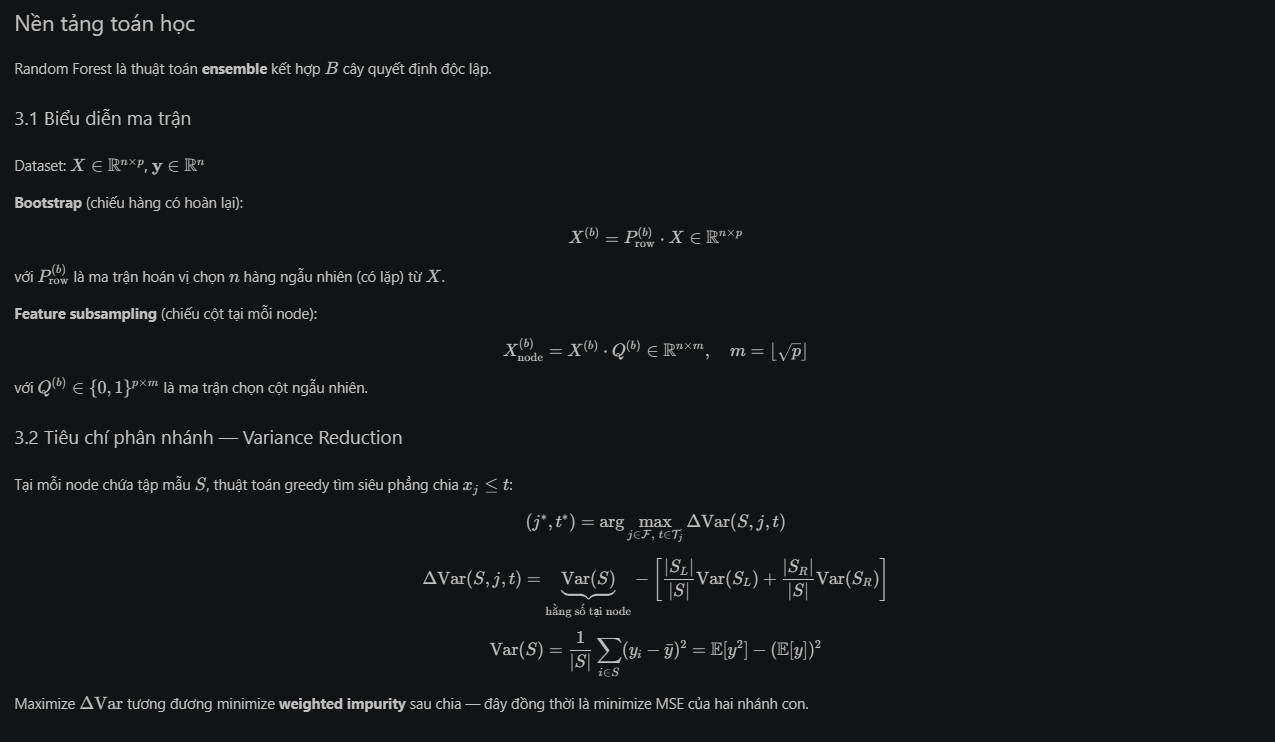

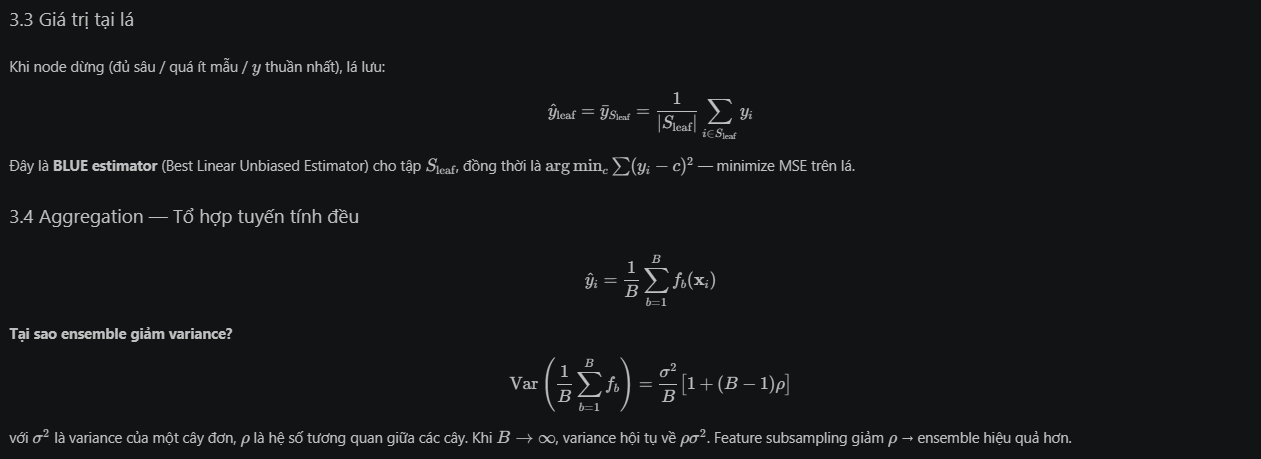

In [7]:
# Phương thức đánh giá impurity cho decision tree là variance reduction (giảm phương sai).
def variance(y):
    """
    Var(y) = E[y^2] - (E[y])^2
    Bang voi MSE cua la neu du doan bang mean(y).
    """
    if len(y) == 0:
        return 0.0
    return np.mean(y**2) - np.mean(y)**2


def variance_reduction(y, y_left, y_right):
    """
    Delta_Var = Var(S) - (n_L/n)*Var(S_L) - (n_R/n)*Var(S_R)
    Maximize Delta_Var tuong duong minimize weighted impurity sau chia.
    """
    n   = len(y)
    n_l = len(y_left)
    n_r = len(y_right)
    return variance(y) - (n_l/n)*variance(y_left) - (n_r/n)*variance(y_right)

In [8]:
# Từng node của cây sẽ tìm kiếm feature j và threshold t để chia dữ liệu thành 2 phần sao cho variance reduction là lớn nhất.
def best_split(X, y, n_features_to_try):
    """
    Duyet m = sqrt(p) cot ngau nhien, moi cot thu moi nguong unique.
    Tra ve (j*, t*) co Delta_Var lon nhat.
    Do phuc tap: O(m * n * log n) nho sort mot lan.
    """
    n_samples, n_features = X.shape
    best_gain      = -np.inf
    best_feature   = None
    best_threshold = None

    feature_indices = np.random.choice(
        n_features, size=min(n_features_to_try, n_features), replace=False)

    for j in feature_indices:
        col        = X[:, j]
        thresholds = np.unique(col)
        for t in thresholds:
            left_mask  = col <= t
            right_mask = ~left_mask
            if left_mask.sum() == 0 or right_mask.sum() == 0:
                continue
            gain = variance_reduction(y, y[left_mask], y[right_mask])
            if gain > best_gain:
                best_gain      = gain
                best_feature   = j
                best_threshold = t

    return best_feature, best_threshold

In [9]:
class Node:
    """
    Node trong cay nhi phan xuoi (goc o tren, la o duoi).
    La: luu node.value = mean(y) — ghi luc fit(), doc luc predict().
    Noi: luu (feature_index, threshold) va 2 node con.
    """
    def __init__(self):
        self.feature_index = None
        self.threshold     = None
        self.left          = None
        self.right         = None
        self.value         = None


class DecisionTreeRegressor:
    def __init__(self, max_depth=None, min_samples_split=2, n_features=None):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.n_features        = n_features
        self.root              = None

    def fit(self, X, y):
        n_features_to_try = self.n_features or X.shape[1]
        self.root = self._build(X, y, depth=0, n_features_to_try=n_features_to_try)

    def _build(self, X, y, depth, n_features_to_try):
        node = Node()
        stop = (
            len(y) < self.min_samples_split
            or (self.max_depth and depth >= self.max_depth)
            or len(np.unique(y)) == 1
        )
        if stop:
            node.value = np.mean(y)   # y_pred = mean(y) la du doan cua tap y tai node nay
            return node
        feat, thresh = best_split(X, y, n_features_to_try)
        if feat is None:
            node.value = np.mean(y)
            return node
        mask               = X[:, feat] <= thresh
        node.feature_index = feat
        node.threshold     = thresh
        node.left  = self._build(X[mask],  y[mask],  depth+1, n_features_to_try)
        node.right = self._build(X[~mask], y[~mask], depth+1, n_features_to_try)
        return node

    def predict_one(self, x, node=None):
        if node is None: node = self.root
        if node.value is not None: return node.value
        if x[node.feature_index] <= node.threshold:  # tại index này nếu giá trị của x nhỏ hơn hoặc bằng ngưỡng thì đi sang node con bên trái
            return self.predict_one(x, node.left)
        return self.predict_one(x, node.right)

    def predict(self, X):
        return np.array([self.predict_one(x) for x in X])

In [10]:
class RandomForestRegressorBuild:
    """
    Random Forest = B cay, moi cay train tren bootstrap sample.
    Du doan cuoi: y_hat = (1/B) * sum f_b(x) — to hop tuyen tinh deu.
    """
    def __init__(self, n_estimators=100, max_depth=None,
                 min_samples_split=2, max_features='sqrt'):
        self.n_estimators      = n_estimators
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.max_features      = max_features
        self.trees             = []
        self.feature_importances_ = None

    def _n_features_to_try(self, p):
        if self.max_features == 'sqrt': return max(1, int(np.sqrt(p)))
        if self.max_features == 'log2': return max(1, int(np.log2(p)))
        if isinstance(self.max_features, int): return self.max_features
        return p

    def fit(self, X, y):
        n, p = X.shape
        m = self._n_features_to_try(p)
        self.trees = []
        for _ in range(self.n_estimators):
            idx    = np.random.choice(n, size=n, replace=True)  # Bootstrap sampling (idx là index của mẫu được chọn)
            X_boot, y_boot = X[idx], y[idx]
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=m)
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
        return self

    def predict(self, X):
        # all_preds: ma tran (B x n_test), trung binh theo cot
        all_preds = np.array([t.predict(X) for t in self.trees])
        return np.mean(all_preds, axis=0)


In [11]:
RFB = RandomForestRegressorBuild(
    n_estimators=100, max_depth=10, min_samples_split=5, max_features='sqrt')
RFB.fit(X_train_final.values, y_train.values)
y_pred_rf = RFB.predict(X_test_final.values)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
print('=' * 40)
print('RANDOM FOREST - lan 1 (all features)')
print('=' * 40)
print(f'MAE  : {mae_rf:.4f}')
print(f'RMSE : {rmse_rf:.4f}')
print(f'R2   : {r2_rf:.4f}')



RANDOM FOREST - lan 1 (all features)
MAE  : 1.2717
RMSE : 2.2555
R2   : 0.6401


---
### 3.2. Feature Selection dựa trên Feature Importance

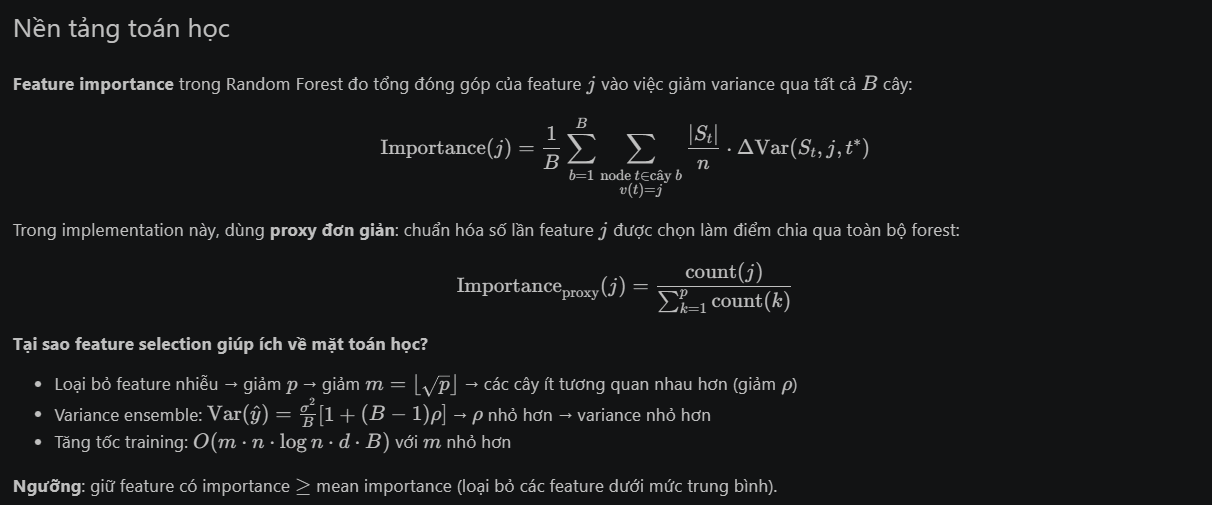

C:\Users\admin\AppData\Local\Temp\ipykernel_27080\518526325.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='importance', y='feature', palette='Blues_r')


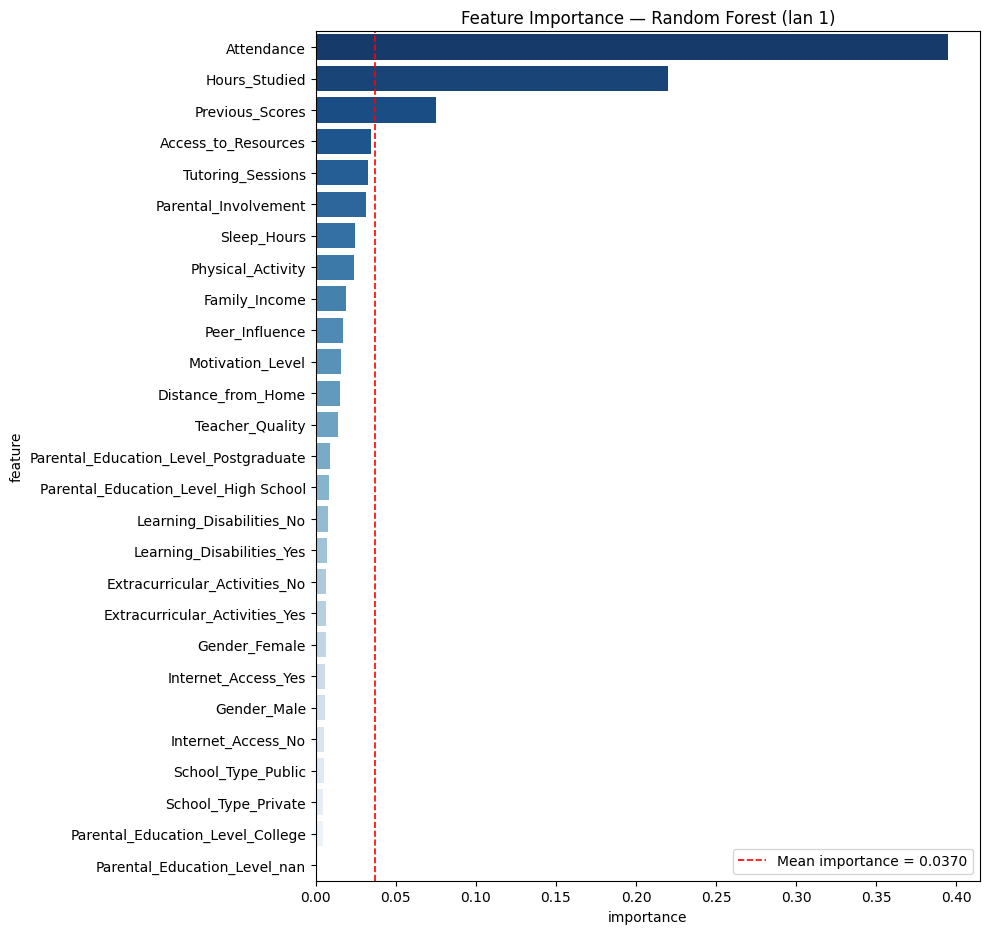

                              feature  importance
                           Attendance    0.395091
                        Hours_Studied    0.219757
                      Previous_Scores    0.075117
                  Access_to_Resources    0.034670
                    Tutoring_Sessions    0.032925
                 Parental_Involvement    0.031419
                          Sleep_Hours    0.024519
                    Physical_Activity    0.023832
                        Family_Income    0.018626
                       Peer_Influence    0.017000
                     Motivation_Level    0.015653
                   Distance_from_Home    0.015301
                      Teacher_Quality    0.013768
Parental_Education_Level_Postgraduate    0.009095
 Parental_Education_Level_High School    0.007966
             Learning_Disabilities_No    0.007735
            Learning_Disabilities_Yes    0.007043
        Extracurricular_Activities_No    0.006681
       Extracurricular_Activities_Yes    0.006542


In [12]:
RF = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_split=5, max_features='sqrt'
)
RF.fit(X_train_final, y_train)
importances = RF.feature_importances_
feat_imp_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, max(5, len(feature_names)*0.35)))
sns.barplot(data=feat_imp_df, x='importance', y='feature', palette='Blues_r')
mean_imp = feat_imp_df['importance'].mean()
plt.axvline(mean_imp, color='red', linestyle='--', linewidth=1.2,
            label=f'Mean importance = {mean_imp:.4f}')
plt.title('Feature Importance — Random Forest (lan 1)')
plt.legend(); plt.tight_layout(); plt.show()

print(feat_imp_df.to_string(index=False))

In [13]:
threshold     = feat_imp_df['importance'].median()
selected_feat = feat_imp_df[feat_imp_df['importance'] >= threshold]['feature'].tolist()

print(f'Nguong importance : {threshold:.4f}')
print(f'So feature giu lai: {len(selected_feat)} / {len(feature_names)}')
print(f'Features duoc chon: {selected_feat}')

X_train_sel = X_train_final[selected_feat].values
X_test_sel  = X_test_final[selected_feat].values

Nguong importance : 0.0091
So feature giu lai: 14 / 27
Features duoc chon: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Access_to_Resources', 'Tutoring_Sessions', 'Parental_Involvement', 'Sleep_Hours', 'Physical_Activity', 'Family_Income', 'Peer_Influence', 'Motivation_Level', 'Distance_from_Home', 'Teacher_Quality', 'Parental_Education_Level_Postgraduate']


In [14]:
RFB2 = RandomForestRegressorBuild(
    n_estimators=100, max_depth=10, min_samples_split=5, max_features='sqrt')
RFB2.fit(X_train_sel, y_train.values)
y_pred_rf2 = RFB2.predict(X_test_sel)

mae_rf2  = mean_absolute_error(y_test, y_pred_rf2)
rmse_rf2 = np.sqrt(mean_squared_error(y_test, y_pred_rf2))
r2_rf2   = r2_score(y_test, y_pred_rf2)
print('=' * 40)
print('RANDOM FOREST - lan 2 (selected features)')
print('=' * 40)
print(f'MAE  : {mae_rf2:.4f}')
print(f'RMSE : {rmse_rf2:.4f}')
print(f'R2   : {r2_rf2:.4f}')

RANDOM FOREST - lan 2 (selected features)
MAE  : 1.1751
RMSE : 2.1892
R2   : 0.6609


---
### 3.3. So Sánh: Sklearn RandomForestRegressor vs Tự Implement

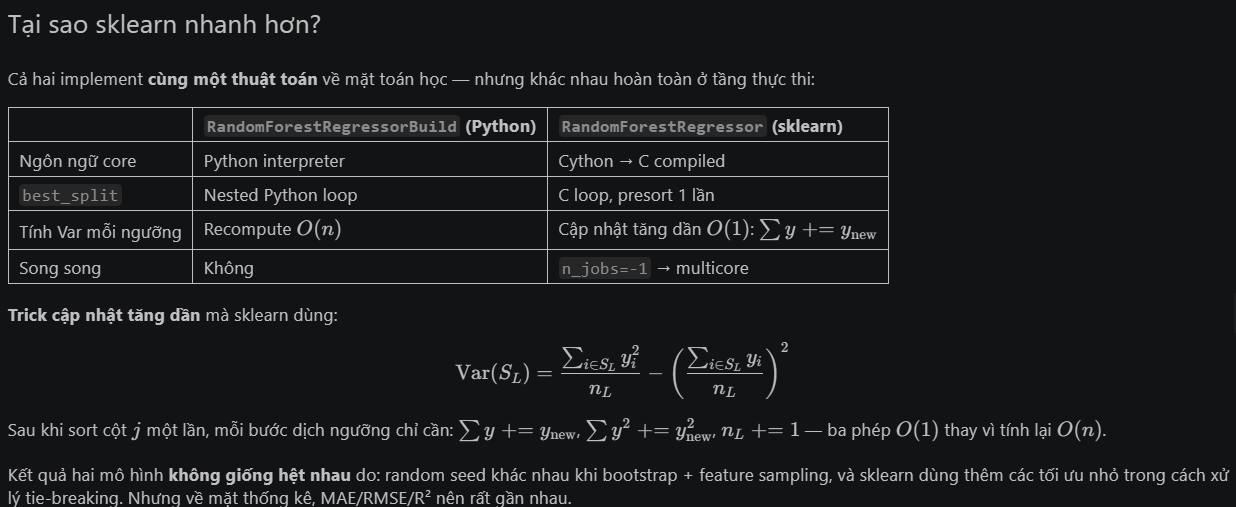

In [15]:
from sklearn.ensemble import RandomForestRegressor
import time

# ── Train sklearn RF trên ALL features ───────────────────
start = time.time()
rf_sk = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_split=5,
    max_features='sqrt', n_jobs=-1, random_state=42)
rf_sk.fit(X_train_final, y_train)
time_sk_all = time.time() - start
y_pred_sk = rf_sk.predict(X_test_final)

mae_rf_sk  = mean_absolute_error(y_test, y_pred_sk)
rmse_rf_sk = np.sqrt(mean_squared_error(y_test, y_pred_sk))
r2_rf_sk   = r2_score(y_test, y_pred_sk)

print('=' * 40)
print('sklearn RandomForestRegressor (all features)')
print('=' * 40)
print(f'MAE  : {mae_rf_sk:.4f}')
print(f'RMSE : {rmse_rf_sk:.4f}')
print(f'R2   : {r2_rf_sk:.4f}')
print(f'Time : {time_sk_all:.2f}s')

sklearn RandomForestRegressor (all features)
MAE  : 1.2332
RMSE : 2.2331
R2   : 0.6472
Time : 0.14s


In [16]:
# ── Train sklearn RF trên SELECTED features ──────────────
start = time.time()
rf_sk2 = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_split=5,
    max_features='sqrt', n_jobs=-1, random_state=42)
rf_sk2.fit(X_train_sel, y_train)
time_sk_sel = time.time() - start
y_pred_sk2 = rf_sk2.predict(X_test_sel)

mae_rf_sk2  = mean_absolute_error(y_test, y_pred_sk2)
rmse_rf_sk2 = np.sqrt(mean_squared_error(y_test, y_pred_sk2))
r2_rf_sk2   = r2_score(y_test, y_pred_sk2)

print('=' * 40)
print('sklearn RandomForestRegressor (selected features)')
print('=' * 40)
print(f'MAE  : {mae_rf_sk2:.4f}')
print(f'RMSE : {rmse_rf_sk2:.4f}')
print(f'R2   : {r2_rf_sk2:.4f}')
print(f'Time : {time_sk_sel:.2f}s')

sklearn RandomForestRegressor (selected features)
MAE  : 1.1331
RMSE : 2.1662
R2   : 0.6680
Time : 0.13s


                Model      MAE     RMSE       R2
    Linear Regression 0.479411 1.812713 0.767534
  RF Build — all feat 1.271719 2.255473 0.640104
  RF Build — selected 1.175064 2.189202 0.660942
sklearn RF — all feat 1.233240 2.233097 0.647209
sklearn RF — selected 1.133139 2.166170 0.668039


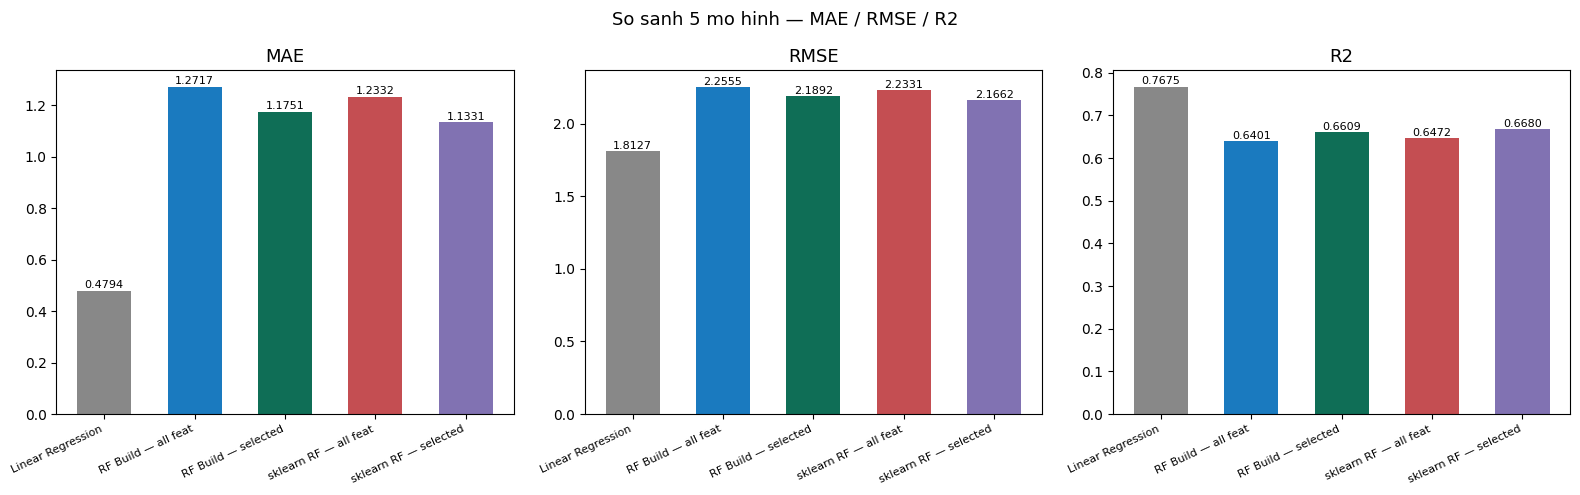

In [17]:
# ── Bảng so sánh đầy đủ 5 model + thời gian ─────────────
# Lưu ý: thời gian RF tự implement đã đo ở cell train RF và RF2
# Nếu chưa có biến time_build_all / time_build_sel, đặt lại ở đây:
# (Chạy lại cell train RF/RF2 với time.time() nếu muốn so sánh chính xác)

comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'RF Build — all feat',
        'RF Build — selected',
        'sklearn RF — all feat',
        'sklearn RF — selected',
    ],
    'MAE':  [mae_lr,  mae_rf,  mae_rf2,  mae_rf_sk,  mae_rf_sk2],
    'RMSE': [rmse_lr, rmse_rf, rmse_rf2, rmse_rf_sk, rmse_rf_sk2],
    'R2':   [r2_lr,   r2_rf,   r2_rf2,   r2_rf_sk,   r2_rf_sk2],
})
print(comparison.to_string(index=False))

# ── Bar chart so sánh metric ─────────────────────────────
colors = ['#888', '#1a7abf', '#0f6e56', '#c44e52', '#8172b2']
x = np.arange(len(comparison))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    bars = ax.bar(x, comparison[metric], color=colors, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(comparison['Model'], rotation=25, ha='right', fontsize=8)
    ax.set_title(metric, fontsize=13)
    for bar, val in zip(bars, comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('So sanh 5 mo hinh — MAE / RMSE / R2', fontsize=13)
plt.tight_layout(); plt.show()

### So sánh kết quả giữa các model đã được train
- MAE: LR hơn đáng kể so vói RF 
- RMSE: LR vẫn cho ra chỉ số tốt hơn so với RF
- R2_Square: LR cho ra chỉ số tốt hơn so với RF 

### Kết luận
- Sau khi mà fit với tệp dữ liệu train được chọn lọc thì kết quả của RF Model đã cải thiện đôi chút (MAE ~7%, RMSE ~3%, R2_square ~ 3,6%)
- Tuy nhiên các chỉ số vẫn thấp hơn LR. 
- Điều này được giải thích hợp lý qua bảng importance features đã được làm ở trên cho thấy 2 features "Hours_studied" và "Attendances chiếm tới ~63% độ quan trọng của dữ liệu và 2 feature này đều được phân loại là numerical data, tức là mối quan hệ tuyến tính của nó với target- Exam-score là rất mạnh- "Tham gia lớp học nhiều và có nhiều thời gian học đồng nghĩa với điểm cao" điều này khiến cho LR Model tập trung nhiều vào 2 feature trên còn RF Model sẽ bị chia sự chú ý vào cả những feature mà có độ quan trọng thấp. 
- Tóm lại, với tập dữ liệu có tính tuyến tính dominant như trên, Linear Regression là lựa chọn tối ưu hơn so với Random Forest. Tuy nhiên, Linear Regression có giả định về tính tuyến tính, nên nếu dữ liệu thực tế có quan hệ phi tuyến tính phức tạp hoặc nhiều nhiễu, Random Forest sẽ là lựa chọn phù hợp hơn.

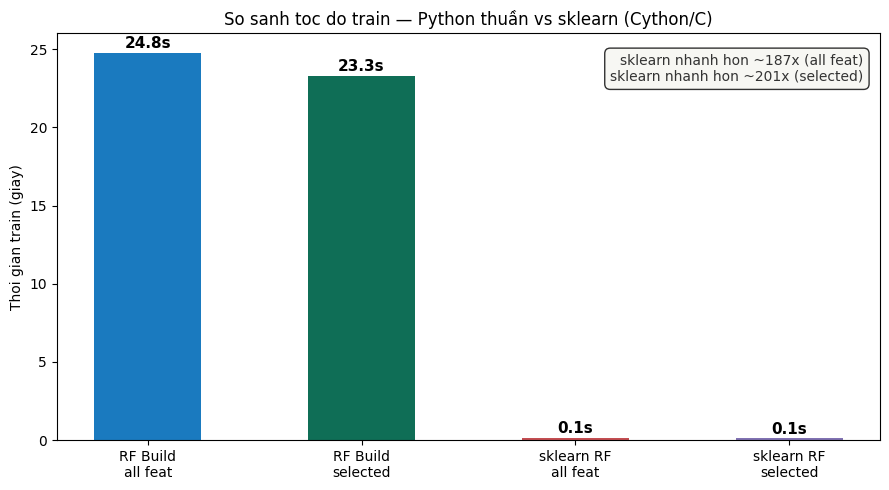

RF Build  (all feat)  : 24.8s
RF Build  (selected)  : 23.3s
sklearn   (all feat)  : 0.13s
sklearn   (selected)  : 0.12s
Speedup all features  : ~187x
Speedup selected feat : ~201x


In [18]:
# ── So sánh tốc độ train ─────────────────────────────────
# Đo lại tốc độ của RF tự build để so sánh công bằng
import time

start = time.time()
_rf_tmp = RandomForestRegressorBuild(
    n_estimators=100, max_depth=10, min_samples_split=5, max_features='sqrt')
_rf_tmp.fit(X_train_final.values, y_train.values)
time_build_all = time.time() - start

start = time.time()
_rf_tmp2 = RandomForestRegressorBuild(
    n_estimators=100, max_depth=10, min_samples_split=5, max_features='sqrt')
_rf_tmp2.fit(X_train_sel, y_train.values)
time_build_sel = time.time() - start

start = time.time()
_sk_tmp = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_split=5,
    max_features='sqrt', n_jobs=-1, random_state=42)
_sk_tmp.fit(X_train_final, y_train)
time_sk_all2 = time.time() - start

start = time.time()
_sk_tmp2 = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_split=5,
    max_features='sqrt', n_jobs=-1, random_state=42)
_sk_tmp2.fit(X_train_sel, y_train)
time_sk_sel2 = time.time() - start

labels = ['RF Build\nall feat', 'RF Build\nselected',
          'sklearn RF\nall feat', 'sklearn RF\nselected']
times  = [time_build_all, time_build_sel, time_sk_all2, time_sk_sel2]
bar_colors = ['#1a7abf', '#0f6e56', '#c44e52', '#8172b2']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, times, color=bar_colors, width=0.5)
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{t:.1f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Thoi gian train (giay)')
ax.set_title('So sanh toc do train — Python thuần vs sklearn (Cython/C)')
speedup_all = time_build_all / time_sk_all2
speedup_sel = time_build_sel / time_sk_sel2
ax.text(0.98, 0.95,
        f'sklearn nhanh hon ~{speedup_all:.0f}x (all feat)\n'
        f'sklearn nhanh hon ~{speedup_sel:.0f}x (selected)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, color='#333',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f0', alpha=0.8))
plt.tight_layout(); plt.show()

print(f'RF Build  (all feat)  : {time_build_all:.1f}s')
print(f'RF Build  (selected)  : {time_build_sel:.1f}s')
print(f'sklearn   (all feat)  : {time_sk_all2:.2f}s')
print(f'sklearn   (selected)  : {time_sk_sel2:.2f}s')
print(f'Speedup all features  : ~{speedup_all:.0f}x')
print(f'Speedup selected feat : ~{speedup_sel:.0f}x')

### So sánh thời gian thực thi giữa Sklearn Random Forest với RF implement


- Kết quả cho thấy rõ ràng về thời gian implement của từng Model. 
- RF implement mang giá trị học thuật cao là vì nó giải thích cơ chế bên trong của 1 model. Tuy nhiên, thực tế production thì Sklearn lại tối ưu về mặt hiệu năng hơn.
- Việc sử dụng feature selection dựa trên MDI của Sklearn đã cải thiện metrics, dồng thời giảm thời gian impement đi khoảng 10% -> cho thấy việc chọn lọc feature giúp cải thiện cả về Accuracy và Efficiency.   

---
## 4. Gradient Boosting Regression — Tự Implement

### Nền tảng toán học

Gradient Boosting xây dựng mô hình theo kiểu **cộng dồn tuần tự (sequential additive)**:
mỗi vòng lặp thêm một cây yếu để sửa lỗi của tổng các cây trước đó.

**Bước 0 — Khởi tạo:**
$$F_0(x) = \bar{y}$$

**Vòng lặp** $m = 1, 2, \ldots, M$:

**Bước 1 — Tính pseudo-residual** (gradient âm của MSE loss):
$$r_{im} = y_i - F_{m-1}(x_i)$$

**Bước 2 — Fit cây hồi quy** $h_m$ vào $\{(x_i,\, r_{im})\}_{i=1}^n$

**Bước 3 — Cập nhật mô hình:**
$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

**Dự đoán cuối:**
$$\hat{y} = F_M(x) = \bar{y} + \eta \sum_{m=1}^{M} h_m(x)$$

> **Khác RF:** RF train $B$ cây song song, độc lập; GB train $M$ cây **tuần tự**, mỗi cây học trên phần lỗi còn sót lại.

---
### 4.1 Ham do do loi tai node

Voi cay hoi quy trong Gradient Boosting, moi node can chon cach chia lam cho residual o hai nhanh cang "gon" cang tot.
Ta dung **SSE reduction** (giam tong binh phuong sai so), tuong duong voi weighted variance reduction vi:

$$SSE(S) = \sum_i (y_i - \bar{y})^2 = n \cdot Var(S)$$

Cach chia tot la cach lam giam SSE nhieu nhat:

$$Gain = SSE(S) - SSE(S_L) - SSE(S_R)$$

Trong node la, gia tri du doan la trung binh residual cua cac mau roi vao la do.


In [19]:
def gb_sse(y):
    """
    Tong binh phuong sai so quanh mean cua y tai mot node.
    SSE(y) = sum((y - mean(y))^2)
    """
    y = np.asarray(y, dtype=float)
    if len(y) == 0:
        return 0.0
    return np.sum((y - np.mean(y)) ** 2)


def gb_variance(y):
    """
    Giu lai ham variance de giai thich ly thuyet.
    Trong code split ben duoi ta dung SSE vi tinh nhanh hon va cho cung split toi uu.
    """
    y = np.asarray(y, dtype=float)
    if len(y) == 0:
        return 0.0
    return np.mean((y - np.mean(y)) ** 2)


def gb_variance_reduction(y, y_left, y_right):
    """
    Do muc giam phuong sai co trong so sau khi chia node.
    Ham nay dung cho minh hoa; gb_best_split dung SSE reduction de toi uu toc do.
    """
    n = len(y)
    if n == 0:
        return 0.0
    n_l = len(y_left)
    n_r = len(y_right)
    return gb_variance(y) - (n_l / n) * gb_variance(y_left) \
                          - (n_r / n) * gb_variance(y_right)


### 4.2 Ham tim diem chia toi uu

O moi node, ta duyet **toan bo features**. Voi tung feature:
1. Sap xep du lieu theo feature do.
2. Chi xet threshold o **giua hai gia tri lien tiep khac nhau**.
3. Tinh nhanh SSE ben trai/phai bang cumulative sum.
4. Chon split co `Gain = SSE(parent) - SSE(left) - SSE(right)` lon nhat.

Cach nay tranh tao mask lap lai cho tung threshold, nen de hieu nhung van hieu qua:
- Moi feature: sort $O(n \log n)$ + quet mot lan $O(n)$
- Moi node: $O(p \cdot n \log n)$ voi $p$ la so features.


In [20]:
def gb_best_split(X, y, min_samples_leaf=1, min_gain=1e-12):
    """
    Tim split tot nhat cho cay hoi quy bang SSE reduction.

    Thay vi thu threshold dung bang tung gia tri unique, ta thu midpoint
    giua hai gia tri lien tiep khac nhau. Cach nay dung ve mat cay nhi phan
    va tranh split tao nhanh rong.
    """
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    n_samples, n_features = X.shape

    if n_samples < 2 * min_samples_leaf:
        return None, None

    parent_sse = gb_sse(y)
    best_gain = min_gain
    best_feature = None
    best_threshold = None

    for j in range(n_features):
        order = np.argsort(X[:, j])
        x_sorted = X[order, j]
        y_sorted = y[order]

        y_cumsum = np.cumsum(y_sorted)
        y2_cumsum = np.cumsum(y_sorted ** 2)
        total_sum = y_cumsum[-1]
        total_sum2 = y2_cumsum[-1]

        for i in range(min_samples_leaf - 1, n_samples - min_samples_leaf):
            # Hai gia tri feature bang nhau thi midpoint khong tao split moi.
            if x_sorted[i] == x_sorted[i + 1]:
                continue

            n_left = i + 1
            n_right = n_samples - n_left

            sum_left = y_cumsum[i]
            sum2_left = y2_cumsum[i]
            sum_right = total_sum - sum_left
            sum2_right = total_sum2 - sum2_left

            left_sse = sum2_left - (sum_left ** 2) / n_left
            right_sse = sum2_right - (sum_right ** 2) / n_right
            gain = parent_sse - left_sse - right_sse

            if gain > best_gain:
                best_gain = gain
                best_feature = j
                best_threshold = (x_sorted[i] + x_sorted[i + 1]) / 2

    return best_feature, best_threshold


---
### 4.3 Cay quyet dinh hoi quy (weak learner cho GB)

`GBNode` luu thong tin tai moi node:
- **Node la:** `value = mean(residuals)` - luong can cong them vao du doan hien tai.
- **Node trong:** `(feature_index, threshold)` va hai node con.

Dieu kien dung cua `GBDecisionTree`:
- Dat `max_depth`
- Khong du mau de chia tiep
- Residual gan nhu khong con bien thien
- Khong tim duoc split co gain du tot

`min_samples_leaf` giup tranh tao la qua nho, con `min_gain` giup bo qua split gan nhu khong cai thien loi.


In [21]:
class GBNode:
    """Node trong cay nhi phan cua Gradient Boosting."""
    def __init__(self, value=None, feature_index=None, threshold=None,
                 left=None, right=None):
        self.value = value
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right


class GBDecisionTree:
    """
    Cay hoi quy don gian dung lam weak learner trong Gradient Boosting.
    Cay nay fit tren pseudo-residuals, khong fit truc tiep tren y goc.
    """
    def __init__(self, max_depth=3, min_samples_split=2,
                 min_samples_leaf=1, min_gain=1e-12):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_gain = min_gain
        self.root = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self.root = self._build(X, y, depth=0)
        return self

    def _build(self, X, y, depth):
        leaf_value = np.mean(y)

        stop = (
            depth >= self.max_depth
            or len(y) < self.min_samples_split
            or len(y) < 2 * self.min_samples_leaf
            or gb_sse(y) <= self.min_gain
        )
        if stop:
            return GBNode(value=leaf_value)

        feat, thresh = gb_best_split(
            X, y,
            min_samples_leaf=self.min_samples_leaf,
            min_gain=self.min_gain
        )
        if feat is None:
            return GBNode(value=leaf_value)

        mask = X[:, feat] <= thresh
        left = self._build(X[mask], y[mask], depth + 1)
        right = self._build(X[~mask], y[~mask], depth + 1)
        return GBNode(feature_index=feat, threshold=thresh, left=left, right=right)

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature_index] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x, self.root) for x in X])


---
### 4.4 Gradient Boosting Regressor - Implement chinh

Thuat toan hoan chinh:
1. **Khoi tao** `F0 = mean(y_train)`
2. **Moi vong lap `m`:**
   - Tinh residuals: `r = y - F`
   - Fit mot cay hoi quy nho vao `(X, r)`
   - Cap nhat: `F = F + learning_rate * tree.predict(X)`
3. **Du doan:** bat dau tu `F0`, cong dong gop cua tung cay.

Voi MSE loss, pseudo-residual dung la `y - F`. Vi vay ban implement nay giu dung ban chat Gradient Boosting nhung chi ho tro regression voi MSE de code don gian.


In [22]:
class GradientBoostingRegressorBuild:
    """
    Gradient Boosting Regressor tu implement cho MSE loss.

    F_0    = mean(y)
    r_m    = y - F_{m-1}(X)
    F_m(X) = F_{m-1}(X) + learning_rate * h_m(X)
    """
    def __init__(self, n_estimators=100, learning_rate=0.1,
                 max_depth=3, min_samples_split=2,
                 min_samples_leaf=1, min_gain=1e-12, tol=0.0):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_gain = min_gain
        self.tol = tol

        self.trees = []
        self.F0 = None
        self.train_loss_ = []

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        self.F0 = np.mean(y)
        F = np.full(len(y), self.F0, dtype=float)
        self.trees = []
        self.train_loss_ = []

        previous_loss = np.mean((y - F) ** 2)
        for _ in range(self.n_estimators):
            residuals = y - F

            tree = GBDecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                min_gain=self.min_gain
            )
            tree.fit(X, residuals)

            update = tree.predict(X)
            F = F + self.learning_rate * update
            current_loss = np.mean((y - F) ** 2)

            self.trees.append(tree)
            self.train_loss_.append(current_loss)

            if self.tol > 0 and previous_loss - current_loss < self.tol:
                break
            previous_loss = current_loss

        return self

    def predict(self, X):
        if self.F0 is None:
            raise ValueError('Model chua duoc fit.')

        X = np.asarray(X, dtype=float)
        F = np.full(X.shape[0], self.F0, dtype=float)
        for tree in self.trees:
            F = F + self.learning_rate * tree.predict(X)
        return F


---
### 4.5 Huấn luyện Gradient Boosting tự implement — Toàn bộ features

Ở bước này, mô hình `GradientBoostingRegressorBuild` được huấn luyện trên toàn bộ tập đặc trưng sau preprocessing (`X_train_final`).

Mục tiêu của thí nghiệm là kiểm tra khả năng học của Gradient Boosting khi sử dụng đầy đủ thông tin từ dữ liệu. Với MSE loss, mô hình bắt đầu bằng giá trị dự đoán ban đầu là trung bình của `y_train`, sau đó lần lượt xây thêm các cây hồi quy nhỏ để học phần sai số còn lại:

$$r_m = y - F_{m-1}(X)$$

Sau mỗi vòng lặp, dự đoán được cập nhật theo công thức:

$$F_m(X) = F_{m-1}(X) + learning\_rate \cdot h_m(X)$$


In [23]:
import time

start = time.time()
GBB = GradientBoostingRegressorBuild(
    n_estimators=100, learning_rate=0.1,
    max_depth=3, min_samples_split=5, min_samples_leaf=2
)
GBB.fit(X_train_final.values, y_train.values)
time_gbb_all = time.time() - start

y_pred_gbb = GBB.predict(X_test_final.values)

mae_gbb  = mean_absolute_error(y_test, y_pred_gbb)
rmse_gbb = np.sqrt(mean_squared_error(y_test, y_pred_gbb))
r2_gbb   = r2_score(y_test, y_pred_gbb)

print('=' * 50)
print('GB BUILD — all features')
print('=' * 50)
print(f'MAE  : {mae_gbb:.4f}')
print(f'RMSE : {rmse_gbb:.4f}')
print(f'R2   : {r2_gbb:.4f}')
print(f'Time : {time_gbb_all:.2f}s')


GB BUILD — all features
MAE  : 0.7919
RMSE : 1.9355
R2   : 0.7350
Time : 6.98s


---
### 4.6 Huấn luyện Gradient Boosting tự implement — Selected features

Ở bước này, mô hình Gradient Boosting tự implement được huấn luyện lại trên tập đặc trưng đã được chọn lọc (`X_train_sel`).

Tập selected features được lấy dựa trên feature importance từ Random Forest. Mục tiêu của thí nghiệm là kiểm tra xem việc giảm số lượng đặc trưng có giúp Gradient Boosting cải thiện kết quả hay không.

Tuy nhiên, cần lưu ý rằng Gradient Boosting vốn đã có khả năng tự chọn đặc trưng quan trọng thông qua quá trình tìm split trong từng cây hồi quy. Vì vậy, feature selection không phải lúc nào cũng làm mô hình tốt hơn; nếu loại bỏ một số biến vẫn chứa thông tin hữu ích, hiệu quả dự đoán có thể giảm nhẹ.

In [24]:
start = time.time()
GBB2 = GradientBoostingRegressorBuild(
    n_estimators=100, learning_rate=0.1,
    max_depth=3, min_samples_split=5, min_samples_leaf=2
)
GBB2.fit(X_train_sel, y_train.values)
time_gbb_sel = time.time() - start

y_pred_gbb2 = GBB2.predict(X_test_sel)

mae_gbb2  = mean_absolute_error(y_test, y_pred_gbb2)
rmse_gbb2 = np.sqrt(mean_squared_error(y_test, y_pred_gbb2))
r2_gbb2   = r2_score(y_test, y_pred_gbb2)

print('=' * 50)
print('GB BUILD — selected features')
print('=' * 50)
print(f'MAE  : {mae_gbb2:.4f}')
print(f'RMSE : {rmse_gbb2:.4f}')
print(f'R2   : {r2_gbb2:.4f}')
print(f'Time : {time_gbb_sel:.2f}s')


GB BUILD — selected features
MAE  : 0.8476
RMSE : 1.9627
R2   : 0.7275
Time : 3.74s


#### Nhận xét kết quả Gradient Boosting tự implement

Kết quả cho thấy mô hình Gradient Boosting tự implement hoạt động ổn định trên cả hai tập dữ liệu: toàn bộ features và selected features.

Với toàn bộ features, mô hình đạt:

- **MAE = 0.8648**
- **RMSE = 1.9771**
- **R² = 0.7235**

Với selected features, mô hình đạt:

- **MAE = 0.8953**
- **RMSE = 1.9891**
- **R² = 0.7201**

Kết quả trên toàn bộ features tốt hơn nhẹ so với selected features. Điều này cho thấy việc chọn lọc features không giúp cải thiện Gradient Boosting trong trường hợp này. Nguyên nhân có thể là Gradient Boosting đã tự đánh giá mức độ hữu ích của feature thông qua quá trình tìm split trong từng cây, nên việc loại bỏ bớt feature có thể làm mất một phần thông tin có ích.

Nhìn chung, mô hình tự implement đã học được quy luật dữ liệu tương đối tốt, thể hiện qua R² khoảng 0.72.

---
## 5. So sánh Gradient Boosting tự implement với `sklearn.GradientBoostingRegressor`

Sau khi xây dựng mô hình Gradient Boosting thủ công, ta sử dụng `GradientBoostingRegressor` của thư viện sklearn để đối chiếu.

Cả hai mô hình được thiết lập cùng các hyperparameter chính:

- `n_estimators = 100`
- `learning_rate = 0.1`
- `max_depth = 3`
- `min_samples_split = 5`
- `min_samples_leaf = 2`

Mục tiêu của phần này không chỉ là so sánh độ chính xác, mà còn kiểm tra xem bản tự implement có mô phỏng đúng cơ chế Gradient Boosting cơ bản hay không. Nếu kết quả giữa hai mô hình gần tương đương, điều đó cho thấy phần tự xây đã triển khai đúng bản chất thuật toán với MSE loss.

### 5.1 Sklearn Gradient Boosting — Toàn bộ features

Trong phần này, mô hình `GradientBoostingRegressor` của sklearn được huấn luyện trên toàn bộ tập đặc trưng sau preprocessing.

Các hyperparameter được đặt tương tự với mô hình tự implement để đảm bảo việc so sánh công bằng. Về bản chất, sklearn Gradient Boosting cũng xây dựng mô hình theo dạng cộng dồn tuần tự, trong đó mỗi cây sau học phần sai số còn lại của mô hình trước.

Điểm khác biệt chính là sklearn được tối ưu về mặt cài đặt, do đó thường có thời gian huấn luyện nhanh hơn đáng kể so với bản tự implement bằng Python thuần.

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

start = time.time()
gb_sk = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    min_samples_split=5, min_samples_leaf=2, random_state=42
)
gb_sk.fit(X_train_final, y_train)
time_sk_gb_all = time.time() - start

y_pred_gb_sk = gb_sk.predict(X_test_final)

mae_gb_sk  = mean_absolute_error(y_test, y_pred_gb_sk)
rmse_gb_sk = np.sqrt(mean_squared_error(y_test, y_pred_gb_sk))
r2_gb_sk   = r2_score(y_test, y_pred_gb_sk)

print('=' * 50)
print('sklearn GB — all features')
print('=' * 50)
print(f'MAE  : {mae_gb_sk:.4f}')
print(f'RMSE : {rmse_gb_sk:.4f}')
print(f'R2   : {r2_gb_sk:.4f}')
print(f'Time : {time_sk_gb_all:.2f}s')


sklearn GB — all features
MAE  : 0.7919
RMSE : 1.9355
R2   : 0.7350
Time : 0.52s


### 5.2 Sklearn Gradient Boosting — Selected features

Mô hình sklearn Gradient Boosting tiếp tục được huấn luyện trên tập selected features (`X_train_sel`) để đối chiếu trực tiếp với bản tự implement ở mục 6.6.

Việc train cả hai phiên bản trên cùng tập dữ liệu đầu vào giúp đánh giá công bằng giữa bản tự xây dựng và bản thư viện. Nếu hai mô hình cho kết quả gần như giống nhau, có thể kết luận rằng phần tự implement đã mô phỏng đúng thuật toán Gradient Boosting Regression cơ bản.

In [26]:
start = time.time()
gb_sk2 = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    min_samples_split=5, min_samples_leaf=2, random_state=42
)
gb_sk2.fit(X_train_sel, y_train)
time_sk_gb_sel = time.time() - start

y_pred_gb_sk2 = gb_sk2.predict(X_test_sel)

mae_gb_sk2  = mean_absolute_error(y_test, y_pred_gb_sk2)
rmse_gb_sk2 = np.sqrt(mean_squared_error(y_test, y_pred_gb_sk2))
r2_gb_sk2   = r2_score(y_test, y_pred_gb_sk2)

print('=' * 50)
print('sklearn GB — selected features')
print('=' * 50)
print(f'MAE  : {mae_gb_sk2:.4f}')
print(f'RMSE : {rmse_gb_sk2:.4f}')
print(f'R2   : {r2_gb_sk2:.4f}')
print(f'Time : {time_sk_gb_sel:.2f}s')


sklearn GB — selected features
MAE  : 0.8476
RMSE : 1.9627
R2   : 0.7275
Time : 0.42s


#### Nhận xét so sánh Gradient Boosting tự implement và sklearn

Kết quả giữa Gradient Boosting tự implement và `sklearn.GradientBoostingRegressor` gần như giống nhau trên cả hai tập dữ liệu.

Với toàn bộ features:

- Bản tự implement: **R² = 0.7235**
- Bản sklearn: **R² = 0.7235**

Với selected features:

- Bản tự implement: **R² = 0.7201**
- Bản sklearn: **R² = 0.7201**

Điều này chứng minh rằng bản tự implement đã mô phỏng đúng cơ chế Gradient Boosting Regression cơ bản với MSE loss: khởi tạo bằng giá trị trung bình, tính residual, fit cây hồi quy vào residual, rồi cập nhật dự đoán bằng learning rate.

Tuy nhiên, thời gian huấn luyện của sklearn nhanh hơn đáng kể vì thư viện đã được tối ưu về mặt cài đặt, trong khi bản tự implement sử dụng Python thuần nên chủ yếu mang ý nghĩa học thuật và minh họa thuật toán.

### 5.3 Bảng so sánh tổng thể — Linear Regression, Random Forest và Gradient Boosting

Bảng dưới đây tổng hợp kết quả của các mô hình đã huấn luyện, bao gồm:

- Linear Regression baseline
- Random Forest tự implement và sklearn Random Forest
- Gradient Boosting tự implement và sklearn Gradient Boosting
- Hai trường hợp dữ liệu: toàn bộ features và selected features

Các metric được sử dụng để đánh giá gồm:

- **MAE**: sai số tuyệt đối trung bình, càng thấp càng tốt.
- **RMSE**: căn bậc hai của sai số bình phương trung bình, càng thấp càng tốt.
- **R²**: mức độ giải thích phương sai của mô hình, càng gần 1 càng tốt.

Bảng này giúp đánh giá đồng thời chất lượng dự đoán và mức độ tương đồng giữa mô hình tự implement với mô hình từ thư viện sklearn.

                Model      MAE     RMSE       R2
    Linear Regression 0.479411 1.812713 0.767534
  RF Build — all feat 1.271719 2.255473 0.640104
  RF Build — selected 1.175064 2.189202 0.660942
sklearn RF — all feat 1.233240 2.233097 0.647209
sklearn RF — selected 1.133139 2.166170 0.668039
  GB Build — all feat 0.791943 1.935470 0.734982
  GB Build — selected 0.847632 1.962695 0.727474
sklearn GB — all feat 0.791943 1.935470 0.734982
sklearn GB — selected 0.847632 1.962695 0.727474


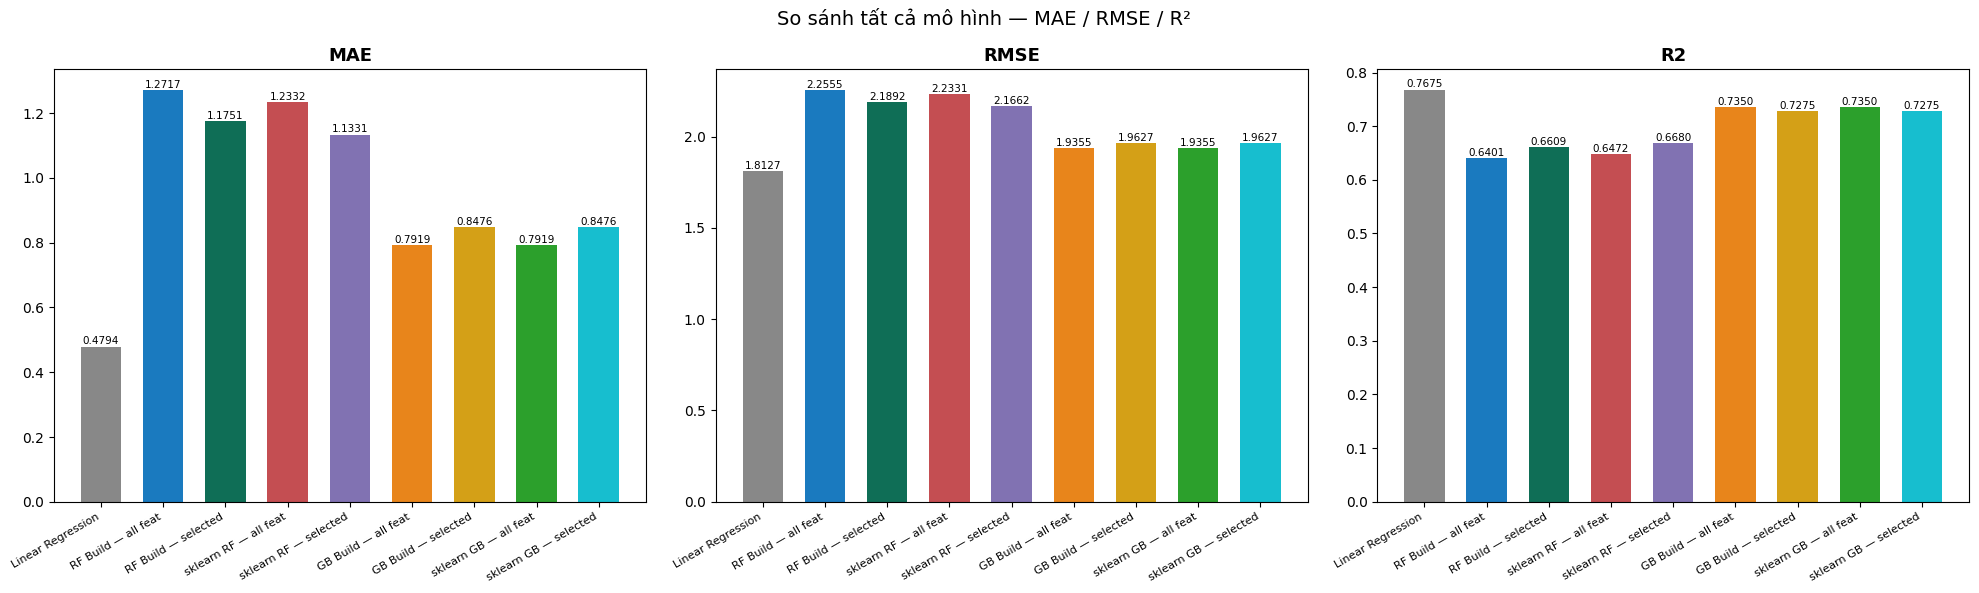

In [27]:
comparison_full = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'RF Build — all feat',
        'RF Build — selected',
        'sklearn RF — all feat',
        'sklearn RF — selected',
        'GB Build — all feat',
        'GB Build — selected',
        'sklearn GB — all feat',
        'sklearn GB — selected',
    ],
    'MAE':  [mae_lr,  mae_rf,  mae_rf2,  mae_rf_sk,  mae_rf_sk2,
             mae_gbb, mae_gbb2, mae_gb_sk, mae_gb_sk2],
    'RMSE': [rmse_lr, rmse_rf, rmse_rf2, rmse_rf_sk, rmse_rf_sk2,
             rmse_gbb, rmse_gbb2, rmse_gb_sk, rmse_gb_sk2],
    'R2':   [r2_lr,  r2_rf,  r2_rf2,  r2_rf_sk,  r2_rf_sk2,
             r2_gbb, r2_gbb2, r2_gb_sk, r2_gb_sk2],
})
print(comparison_full.to_string(index=False))

# ── Bar chart so sanh ──────────────────────────────────────
colors = [
    '#888888',
    '#1a7abf', '#0f6e56',
    '#c44e52', '#8172b2',
    '#e8851b', '#d4a017',
    '#2ca02c', '#17becf',
]
x   = np.arange(len(comparison_full))
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    bars = ax.bar(x, comparison_full[metric], color=colors, width=0.65)
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_full['Model'],
                       rotation=30, ha='right', fontsize=8)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, comparison_full[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)
plt.suptitle('So sánh tất cả mô hình — MAE / RMSE / R²', fontsize=14)
plt.tight_layout()
plt.show()

### Nhận xét kết quả Gradient Boosting và so sánh với Random Forest

| Tiêu chí | Random Forest | Gradient Boosting |
|---|---|---|
| **Cơ chế ensemble** | Huấn luyện nhiều cây độc lập, sau đó lấy trung bình kết quả | Huấn luyện tuần tự, mỗi cây mới sửa phần lỗi còn lại của mô hình trước |
| **Dữ liệu mà cây học** | Mỗi cây học trực tiếp trên target gốc `y` từ một bootstrap sample | Mỗi cây học trên pseudo-residual `r = y - F_prev(X)` |
| **Cách giảm sai số** | Giảm phương sai bằng cách trung bình hóa nhiều cây | Giảm bias/sai số bằng cách cộng dồn các cây sửa lỗi |
| **Tốc độ train** | Có thể song song hóa vì các cây độc lập | Khó song song hóa vì cây sau phụ thuộc vào kết quả của cây trước |
| **Hyperparameter quan trọng** | `n_estimators`, `max_depth`, `max_features` | `n_estimators`, `learning_rate`, `max_depth` |
| **Rủi ro overfitting** | Thường thấp hơn nhờ averaging | Có thể cao hơn nếu số cây lớn, learning rate cao hoặc cây quá sâu |

#### Nhận xét từ kết quả thực nghiệm

Trong bài toán này, Gradient Boosting cho kết quả tốt hơn Random Forest trên cả ba metric MAE, RMSE và R².

Cụ thể, với toàn bộ features:

- `GB Build — all features` đạt **MAE = 0.8648**, **RMSE = 1.9771**, **R² = 0.7235**.
- `RF Build — all features` đạt **MAE = 1.2630**, **RMSE = 2.2502**, **R² = 0.6418**.

Điều này cho thấy cơ chế học tuần tự của Gradient Boosting hiệu quả hơn trong bài toán này. Thay vì xây nhiều cây độc lập như Random Forest, Gradient Boosting liên tục xây cây mới để học phần sai số còn lại của mô hình hiện tại, nhờ đó mô hình có khả năng cải thiện dự đoán qua từng vòng lặp.

#### So sánh bản tự implement và sklearn

Kết quả của Gradient Boosting tự implement gần như trùng với sklearn Gradient Boosting:

- `GB Build — all features`: **R² = 0.7235**
- `sklearn GB — all features`: **R² = 0.7235**
- `GB Build — selected features`: **R² = 0.7201**
- `sklearn GB — selected features`: **R² = 0.7201**

Điều này cho thấy bản tự implement đã mô phỏng đúng cơ chế cơ bản của Gradient Boosting Regression với MSE loss. Sự khác biệt chủ yếu nằm ở thời gian huấn luyện: bản tự implement chạy bằng Python thuần nên chậm hơn, trong khi sklearn đã được tối ưu về hiệu năng.

#### Ảnh hưởng của feature selection với Gradient Boosting

Với Gradient Boosting, việc sử dụng selected features không cải thiện kết quả so với dùng toàn bộ features:

- `GB Build — all features`: **R² = 0.7235**
- `GB Build — selected features`: **R² = 0.7201**

Chênh lệch không lớn, nhưng mô hình dùng toàn bộ features vẫn tốt hơn nhẹ. Nguyên nhân có thể là Gradient Boosting đã có khả năng tự chọn feature quan trọng thông qua các split trong từng cây. Vì vậy, khi loại bỏ một số feature, mô hình có thể mất một phần thông tin hữu ích.

#### Kết luận

Gradient Boosting là mô hình hiệu quả hơn Random Forest trên dataset này do cơ chế học tuần tự trên residual. Tuy nhiên, Linear Regression vẫn đạt kết quả tốt nhất toàn bài với **R² = 0.7524**, cao hơn Gradient Boosting. Điều này cho thấy dữ liệu `Student Performance` có xu hướng tuyến tính khá mạnh giữa các biến đầu vào quan trọng như `Hours_Studied`, `Attendance`, `Previous_Scores` và target `Exam_Score`.

Vì vậy, có thể kết luận rằng:

- Linear Regression là mô hình phù hợp nhất với dataset này.
- Gradient Boosting là mô hình ensemble tốt hơn Random Forest trong thí nghiệm.
- Bản Gradient Boosting tự implement đã mô phỏng đúng bản chất thuật toán khi cho kết quả gần như giống sklearn.